In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [23]:
areas_to_districts = {
    "Kwai Tsing": ["Tsing Yi", "Kwai Chung East", "Kwai Chung West"],
    "North": ["Wu Tip Shan", "Robin's Nest"],
    "Sai Kung": ["Sai Kung and Hang Hau", "Tseung Kwan O South", "Tseung Kwan O North", "Hang Hau"],
    "Sha Tin": ['Sha Tin West', 'Sha Tin East', 'Sha Tin South', 'Sha Tin North'],
    "Tai Po": ['Tai Po South', 'Tai Po North'],
    "Tsuen Wan": ['Tsuen Wan Northwest', 'Tsuen Wan Southeast'],
    "Tuen Mun": ['Tuen Mun East', 'Tuen Mun West', 'Tuen Mun North'],
    "Yuen Long": ['Yuen Long Town Centre', 'Yuen Long Rural East', 'Tin Shui Wai South and Ping Ha'],
    "Kowloon City": ['Kowloon City North', 'Kowloon City South'],
    "Kwun Tong": ['Kwun Tong Southeast', 'Kwun Tong Central', 'Kwun Tong North', 'Kwun Tong West'],
    "Sham Shui Po": ['Sham Shui Po West', 'Sham Shui Po East'],
    "Wong Tai Sin": ['Wong Tai Sin East', 'Wong Tai Sin West'],
    "Yau Tsim Mong": ['Yau Tsim Mong South', 'Yau Tsim Mong North'],
    "Central and Western": ['Central', 'Western'],
    "Eastern": ['Tai Pak', 'Hong Wan', 'Chai Wan'],
    "Southern": ['Southern District Southeast', 'Southern District Northwest'],
    "Wan Chai": ['Wan Chai'],
    "Islands": ['Islands']
}

district_to_area = {}
for area, districts in areas_to_districts.items():
    for district in districts:
        district_to_area[district] = area

data = pd.read_csv('final_transport_data.csv')

# Add area information to the data
data['AREA'] = data['DISTRICT'].map(district_to_area)
data['NEXT AREA'] = data['NEXT DISTRICT'].map(district_to_area)

# Group by source and destination districts and calculate the average price
average_prices = data.groupby(['AREA', 'DISTRICT', 'NEXT AREA', 'NEXT DISTRICT'])['PRICE'].mean().reset_index()

# Multiply all average prices by 42
average_prices['PRICE'] = average_prices['PRICE'] * 40

# Get unique areas
areas = sorted(average_prices['AREA'].unique())

area_transportation_cost = {
    "Kwai Tsing": 639.6074225,
    "North": 627.3072798, 
    "Sai Kung": 925.3100484,
    "Sha Tin": 723.5119676,
    "Tai Po": 751.9780123, 
    "Tsuen Wan": 816.0266127, 
    "Tuen Mun": 676.9809331, 
    "Yuen Long": 714.0232861, 
    "Kowloon City": 755.2287643, 
    "Kwun Tong": 590.4068516, 
    "Sham Shui Po": 640.2962305, 
    "Wong Tai Sin": 617.4671656, 
    "Yau Tsim Mong": 815.6470654, 
    "Central and Western": 1088.278783, 
    "Eastern": 801.7935904,
    "Southern": 824.5337065, 
    "Wan Chai": 1034.631237, 
    "Islands": 774.9089927
}

C:\Users\kelvin wong\AppData\Local\Temp\ipykernel_6004\3120879025.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Transportation Cost', y='Area', data=transport_cost, palette='viridis')


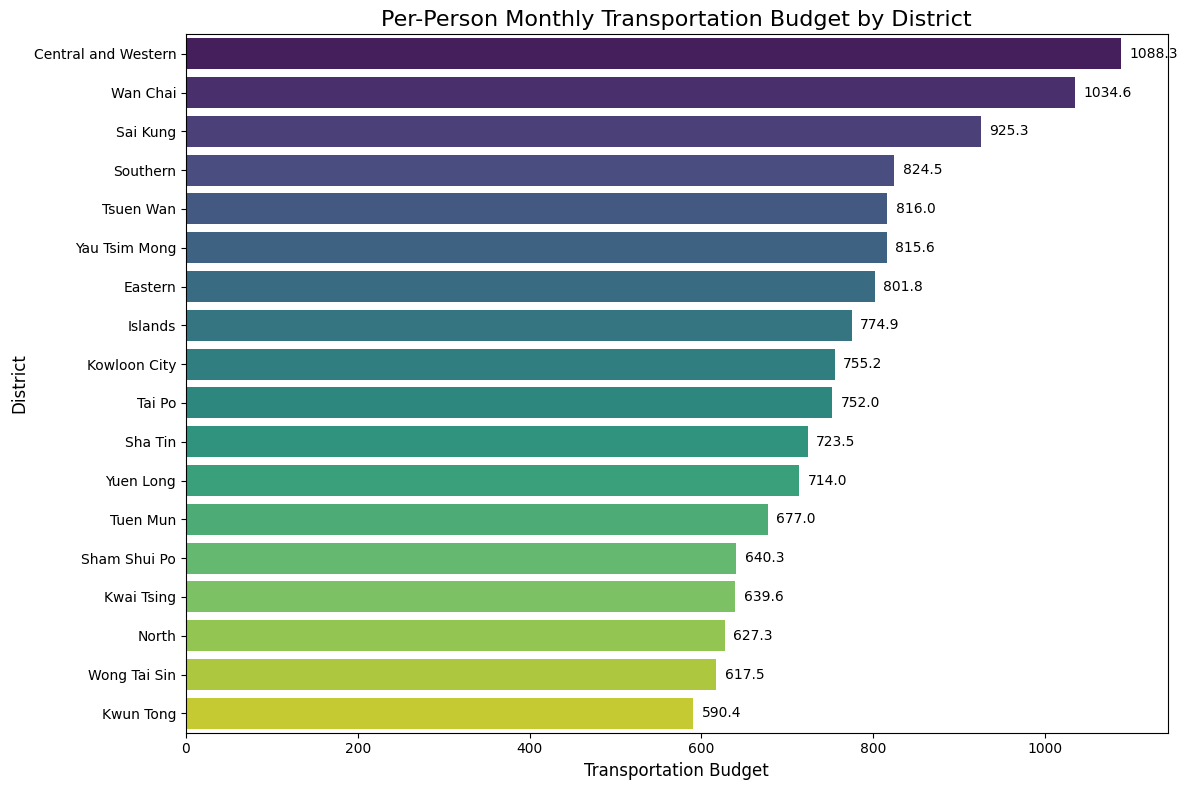

In [24]:
transport_cost = pd.DataFrame(list(area_transportation_cost.items()), columns=['Area', 'Transportation Cost'])

# Sort by cost for better visualization
transport_cost = transport_cost.sort_values('Transportation Cost', ascending=False)

# Create figure
plt.figure(figsize=(12, 8))

# Create bar plot
sns.barplot(x='Transportation Cost', y='Area', data=transport_cost, palette='viridis')

# Add title and labels
plt.title('Per-Person Monthly Transportation Budget by District', fontsize=16)
plt.xlabel('Transportation Budget', fontsize=12)
plt.ylabel('District', fontsize=12)

# Add value labels
for i, v in enumerate(transport_cost['Transportation Cost']):
    plt.text(v + 10, i, f"{v:.1f}", color='black', va='center')

plt.tight_layout()
plt.show()

In [25]:
# Create a list to store pairs of constituencies with costs exceeding the budget
exceeding_budget_pairs = []

# Iterate through each area
for area in areas:
    # Filter data for the current area
    area_data = average_prices[average_prices['AREA'] == area].copy()
    
    # Get the transportation budget for the area
    transport_cost = area_transportation_cost[area]
    
    # Check for rows where the price exceeds the transportation budget
    for _, row in area_data.iterrows():
        if row['PRICE'] > transport_cost:
            # Add the pair (start constituency, end constituency) to the list
            exceeding_budget_pairs.append((row['DISTRICT'], row['NEXT DISTRICT']))

# Print the list of pairs
print("Pairs of constituencies exceeding the transportation budget:")
print(exceeding_budget_pairs)

# print the number of pairs
print(f"Number of pairs exceeding the transportation budget: {len(exceeding_budget_pairs)}")
# Convert the list of exceeding budget pairs to a DataFrame
exceeding_budget_df = pd.DataFrame(exceeding_budget_pairs, columns=['DISTRICT', 'NEXT DISTRICT'])

# Save the DataFrame to a CSV file
exceeding_budget_df.to_csv('expensiveset.csv', index=False)

print("Results have been saved to expensiveset.csv")

Pairs of constituencies exceeding the transportation budget:
[('Central', 'Tai Po North'), ('Central', 'Tuen Mun East'), ('Central', 'Tin Shui Wai South and Ping Ha'), ('Central', 'Yuen Long Rural East'), ('Central', 'Yuen Long Town Centre'), ('Western', 'Tuen Mun East'), ('Western', 'Tuen Mun North'), ('Western', 'Tin Shui Wai South and Ping Ha'), ('Western', 'Yuen Long Rural East'), ('Western', 'Yuen Long Town Centre'), ('Chai Wan', 'Sha Tin East'), ('Chai Wan', 'Sha Tin North'), ('Chai Wan', 'Sha Tin South'), ('Chai Wan', 'Sha Tin West'), ('Chai Wan', 'Tai Po North'), ('Chai Wan', 'Tai Po South'), ('Chai Wan', 'Tsuen Wan Northwest'), ('Chai Wan', 'Yuen Long Rural East'), ('Chai Wan', 'Yuen Long Town Centre'), ('Hong Wan', 'Islands'), ('Hong Wan', 'Tsing Yi'), ('Hong Wan', 'Wu Tip Shan'), ('Hong Wan', 'Sha Tin East'), ('Hong Wan', 'Sha Tin North'), ('Hong Wan', 'Sha Tin South'), ('Hong Wan', 'Sha Tin West'), ('Hong Wan', 'Tai Po North'), ('Hong Wan', 'Tai Po South'), ('Hong Wan', 'Ts

In [26]:
# Print the total number of pairs  
total_pairs = average_prices.shape[0]
print(f"Total number of pairs: {total_pairs}")

# Print out the number of pairs that exceed the budget for each starting area 
for area in areas:
    # Filter data for the current area
    area_data = average_prices[average_prices['AREA'] == area].copy()
    
    # Get the transportation budget for the area
    transport_cost = area_transportation_cost[area]
    
    # Count the number of pairs that exceed the budget
    count_exceeding_budget = area_data[area_data['PRICE'] > transport_cost].shape[0]
    
    # Print the result
    print(f"Number of pairs exceeding the transportation budget for {area}: {count_exceeding_budget}")
    


Total number of pairs: 1742
Number of pairs exceeding the transportation budget for Central and Western: 10
Number of pairs exceeding the transportation budget for Eastern: 46
Number of pairs exceeding the transportation budget for Islands: 25
Number of pairs exceeding the transportation budget for Kowloon City: 13
Number of pairs exceeding the transportation budget for Kwai Tsing: 20
Number of pairs exceeding the transportation budget for Kwun Tong: 42
Number of pairs exceeding the transportation budget for North: 39
Number of pairs exceeding the transportation budget for Sai Kung: 15
Number of pairs exceeding the transportation budget for Sha Tin: 58
Number of pairs exceeding the transportation budget for Sham Shui Po: 14
Number of pairs exceeding the transportation budget for Southern: 41
Number of pairs exceeding the transportation budget for Tai Po: 28
Number of pairs exceeding the transportation budget for Tsuen Wan: 15
Number of pairs exceeding the transportation budget for Tuen

Number of exceeding budget pairs by starting DISTRICT:
                      DISTRICT  Count
                 Tuen Mun West     28
   Southern District Northwest     26
                       Islands     25
          Yuen Long Rural East     24
                       Tai Pak     21
                  Robin's Nest     21
                   Wu Tip Shan     18
                 Tuen Mun East     17
                  Tai Po North     17
                      Hong Wan     16
                 Sha Tin South     15
         Yuen Long Town Centre     15
   Southern District Southeast     15
                  Sha Tin East     15
                Tuen Mun North     15
                  Sha Tin West     14
Tin Shui Wai South and Ping Ha     14
                 Sha Tin North     14
           Tsuen Wan Northwest     13
           Kwun Tong Southeast     13
             Kwun Tong Central     13
                  Tai Po South     11
             Wong Tai Sin West     11
                Kwun Tong West   

C:\Users\kelvin wong\AppData\Local\Temp\ipykernel_6004\1440935272.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=exceeding_df, y='DISTRICT', x='Count', palette='mako')


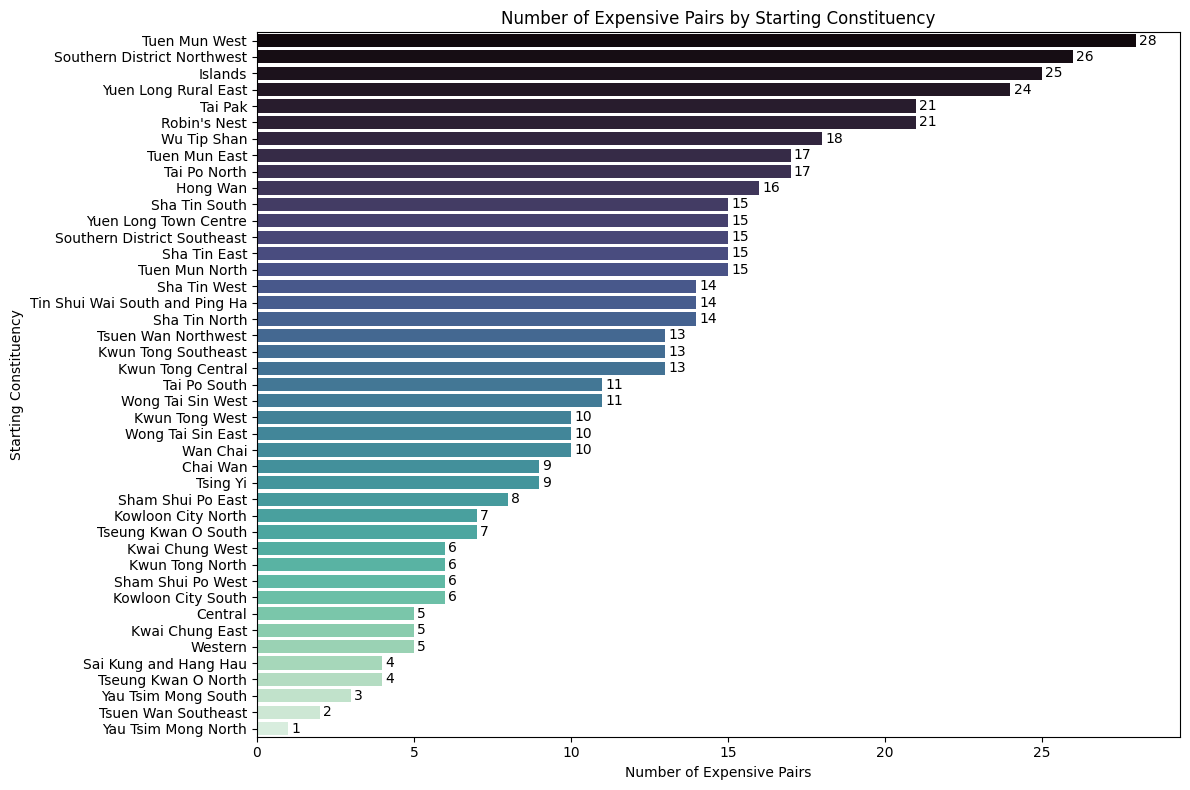

In [27]:
# Count the number of exceeding pairs for each starting DISTRICT
from collections import defaultdict

exceeding_counts = defaultdict(int)
for start_district, _ in exceeding_budget_pairs:
    exceeding_counts[start_district] += 1

# Convert to a DataFrame for easier handling
exceeding_df = pd.DataFrame.from_dict(exceeding_counts, 
                                     orient='index', 
                                     columns=['Count']).reset_index()
exceeding_df = exceeding_df.rename(columns={'index': 'DISTRICT'})

# Sort by count in descending order
exceeding_df = exceeding_df.sort_values('Count', ascending=False)

# Print the results
print("Number of exceeding budget pairs by starting DISTRICT:")
print(exceeding_df.to_string(index=False))

# Plot the results with value labels
plt.figure(figsize=(12, 8))
ax = sns.barplot(data=exceeding_df, y='DISTRICT', x='Count', palette='mako')

# Add value labels to each bar
for p in ax.patches:
    width = p.get_width()
    if width > 0:  # Only label bars with positive values
        ax.text(width + 0.1,  # x-position (just right of the bar)
                p.get_y() + p.get_height()/2,  # y-position (middle of the bar)
                f'{int(width)}',  # Text (the count value)
                ha='left',  # Horizontal alignment
                va='center')  # Vertical alignment

plt.title('Number of Expensive Pairs by Starting Constituency')
plt.xlabel('Number of Expensive Pairs')
plt.ylabel('Starting Constituency')
plt.tight_layout()
plt.show()

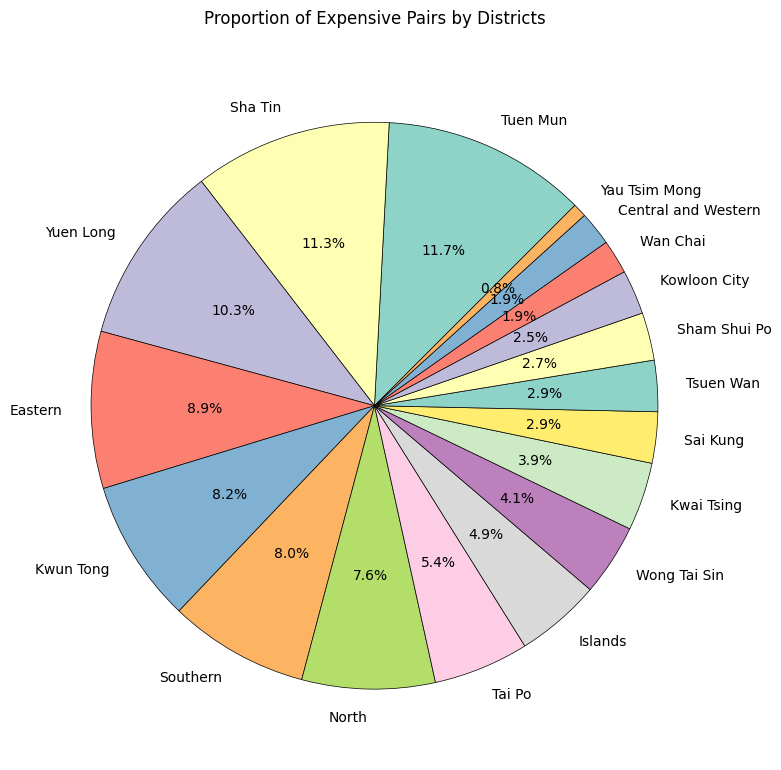

In [28]:
# Initialize a dictionary to store counts
area_exceeding_counts = {}

for area in areas:
    # Filter data for the current area
    area_data = average_prices[average_prices['AREA'] == area].copy()
    
    # Get the transportation budget for the area
    transport_cost = area_transportation_cost[area]
    
    # Count the number of pairs that exceed the budget
    count_exceeding_budget = area_data[area_data['PRICE'] > transport_cost].shape[0]
    
    # Store the count
    area_exceeding_counts[area] = count_exceeding_budget

# Convert to DataFrame for plotting
area_exceeding_df = pd.DataFrame.from_dict(area_exceeding_counts, orient='index', columns=['Count']).reset_index()
area_exceeding_df.columns = ['AREA', 'Count']

# Sort by count (descending)
area_exceeding_df = area_exceeding_df.sort_values('Count', ascending=False)

plt.figure(figsize=(8, 8))
plt.pie(
    area_exceeding_df['Count'],
    labels=area_exceeding_df['AREA'],
    autopct='%1.1f%%',
    startangle=45,
    colors=sns.color_palette("Set3"),  # Pastel colors
    wedgeprops={'edgecolor': 'black', 'linewidth': 0.5}
)
plt.title('Proportion of Expensive Pairs by Districts', pad=20)
plt.tight_layout()
plt.show()

C:\Users\kelvin wong\AppData\Local\Temp\ipykernel_6004\659547666.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


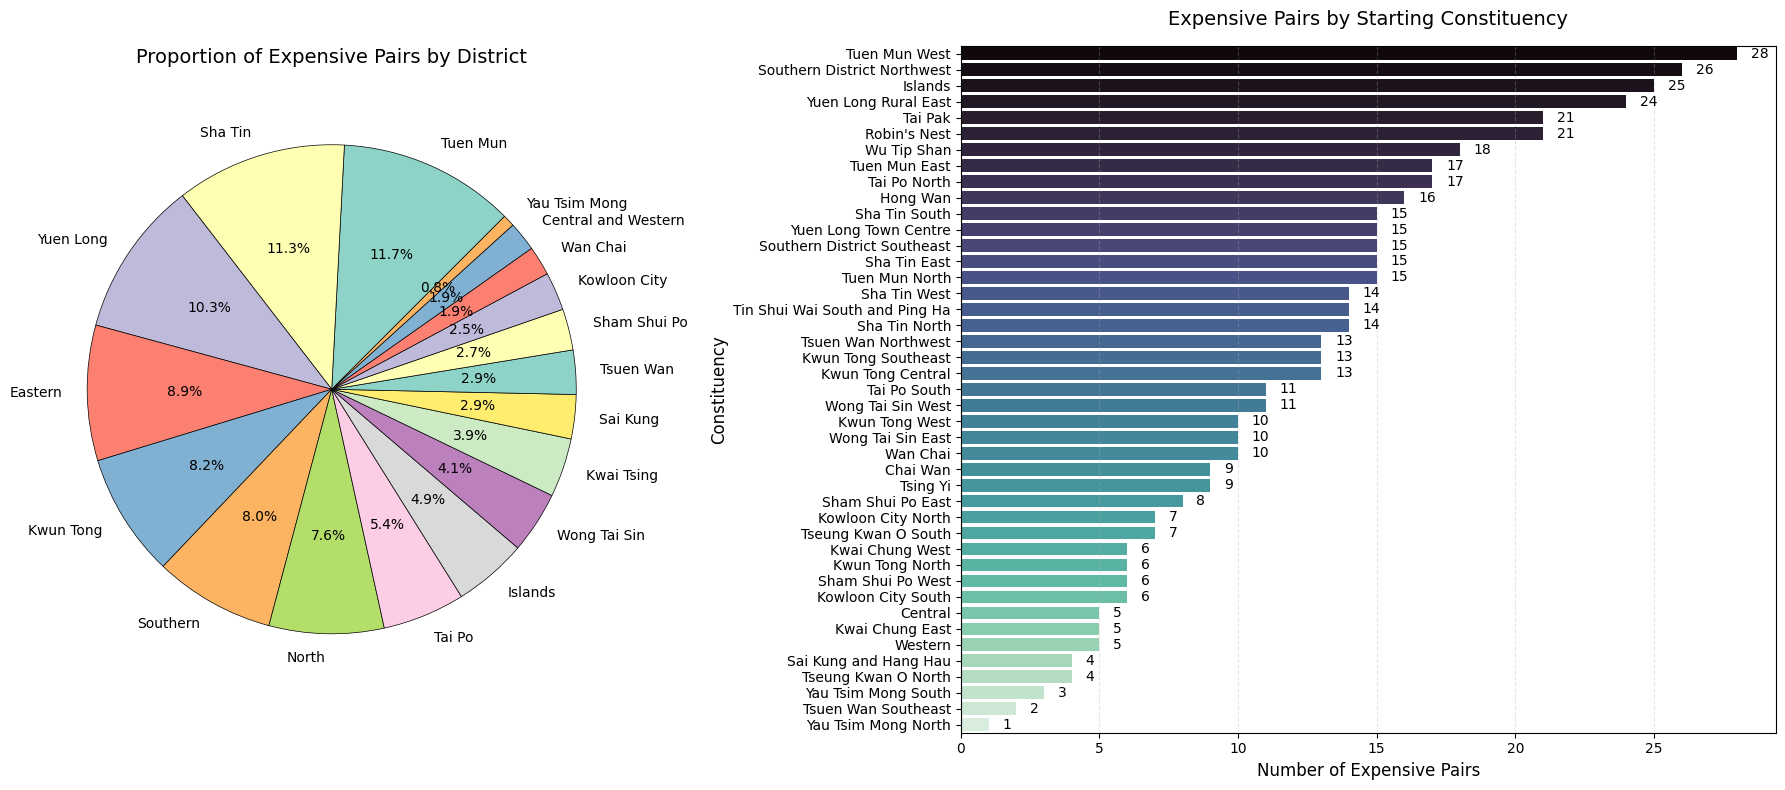

In [29]:
# Create figure with 1 row and 2 columns (pie on left, bar on right)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8), gridspec_kw={'width_ratios': [1.5, 2]})

# --- Plot 1: Pie Chart (By Area) ---
# Define explode for small slices (adjust threshold as needed)
explode = [0.05 if count < max(area_exceeding_df['Count'])/3 else 0 for count in area_exceeding_df['Count']]

wedges, texts, autotexts = ax1.pie(
    area_exceeding_df['Count'],
    labels=area_exceeding_df['AREA'],
    autopct='%1.1f%%',
    startangle=45,
    colors=sns.color_palette("Set3"),  # Pastel colors
    wedgeprops={'edgecolor': 'black', 'linewidth': 0.5}
    # explode=explode,  # Separate small slices
    # labeldistance=1.1,  # Push labels outward
    # textprops={'fontsize': 9, 'ha': 'center'}  # Smaller font + center alignment
)

# Improve label readability (optional: rotate labels)
# for text in texts:
#     text.set_rotation_mode('anchor')
#     text.set_rotation(45)  # Rotate labels by 45 degrees

ax1.set_title('Proportion of Expensive Pairs by District', pad=15, fontsize=14)

# --- Plot 2: Bar Chart (By District) ---
sns.barplot(
    data=exceeding_df,
    y='DISTRICT',
    x='Count',
    palette="mako",
    ax=ax2
)

# Add value labels to bars
for p in ax2.patches:
    width = p.get_width()
    if width > 0:
        ax2.text(
            width + 0.5,
            p.get_y() + p.get_height()/2,
            f'{int(width)}',
            ha='left',
            va='center',
            fontsize=10
        )

ax2.set_title('Expensive Pairs by Starting Constituency', pad=15, fontsize=14)
ax2.set_xlabel('Number of Expensive Pairs', fontsize=12)
ax2.set_ylabel('Constituency', fontsize=12)
ax2.grid(axis='x', linestyle='--', alpha=0.3)

# Adjust layout
plt.tight_layout()
plt.show()

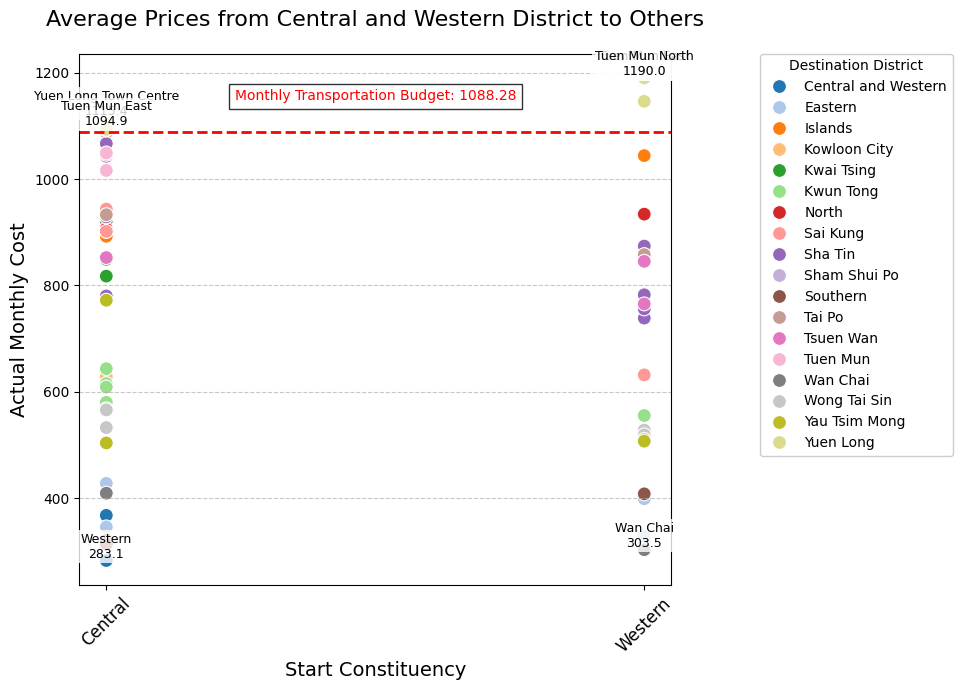

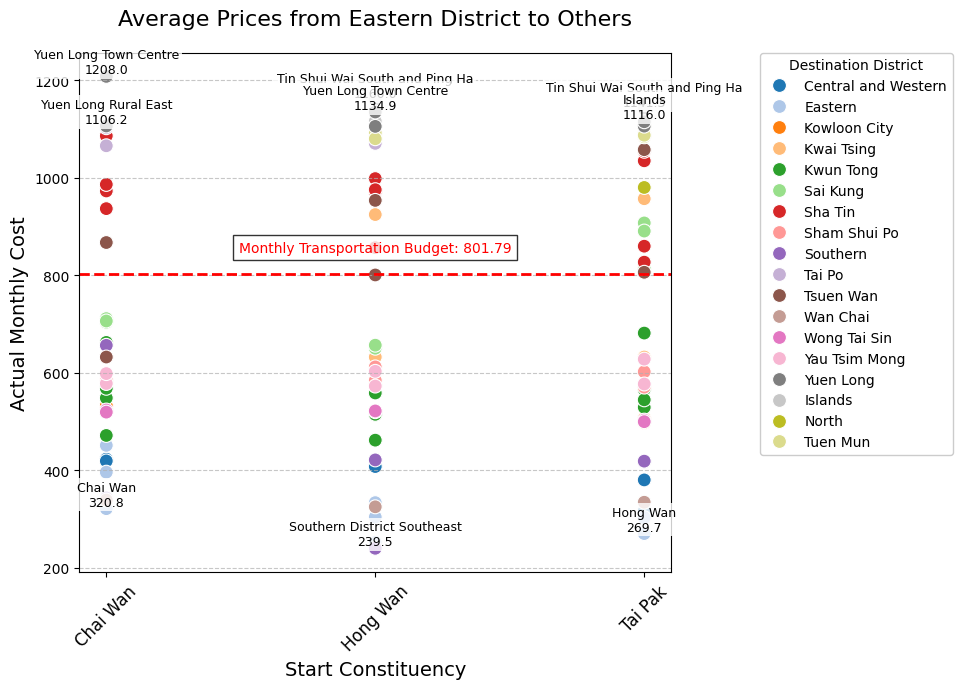

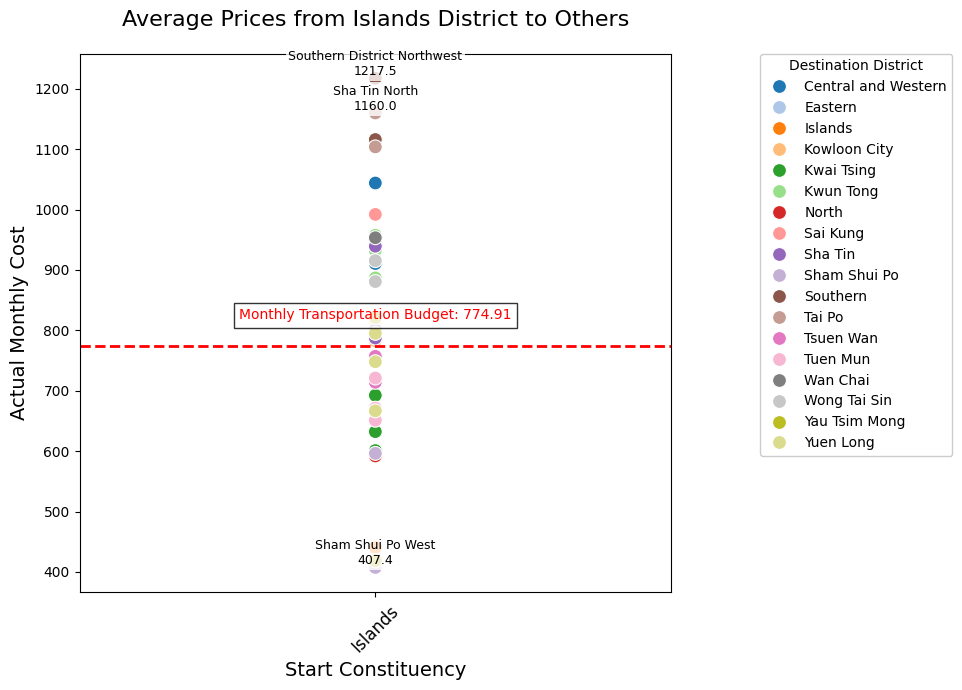

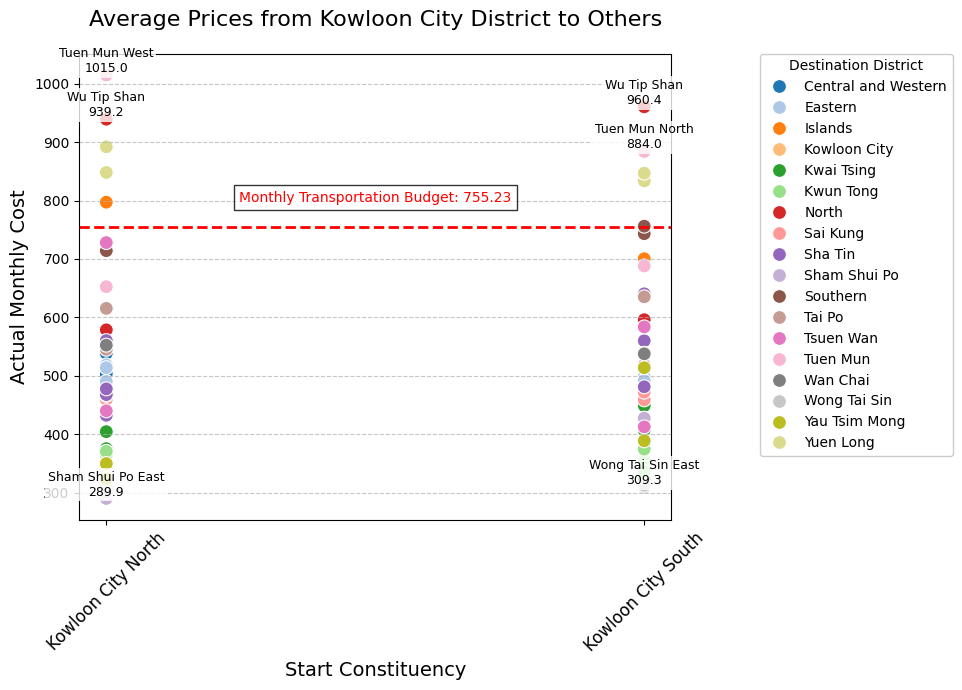

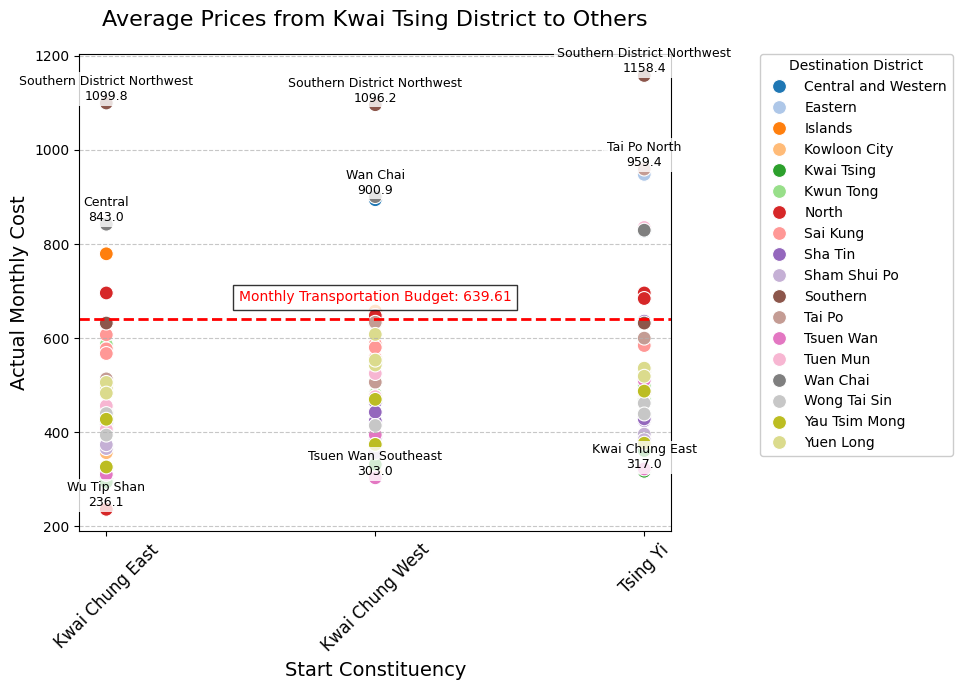

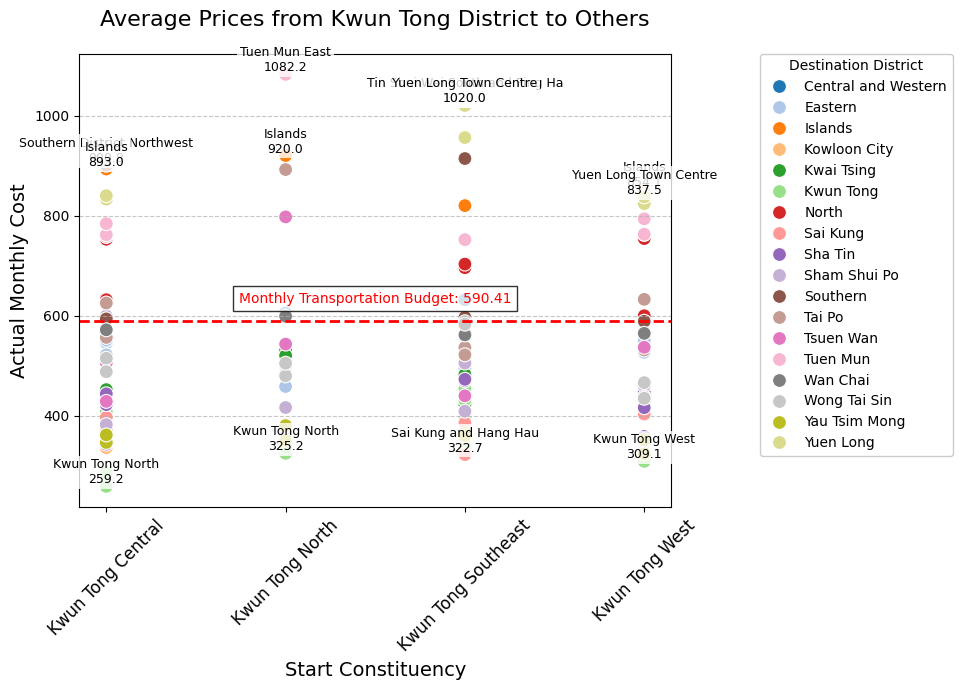

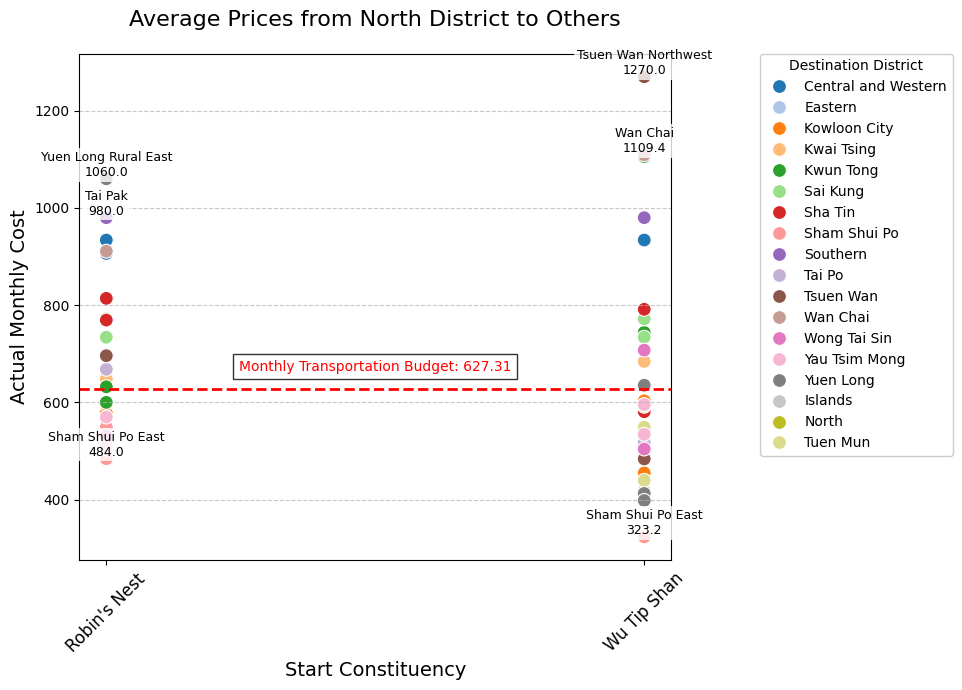

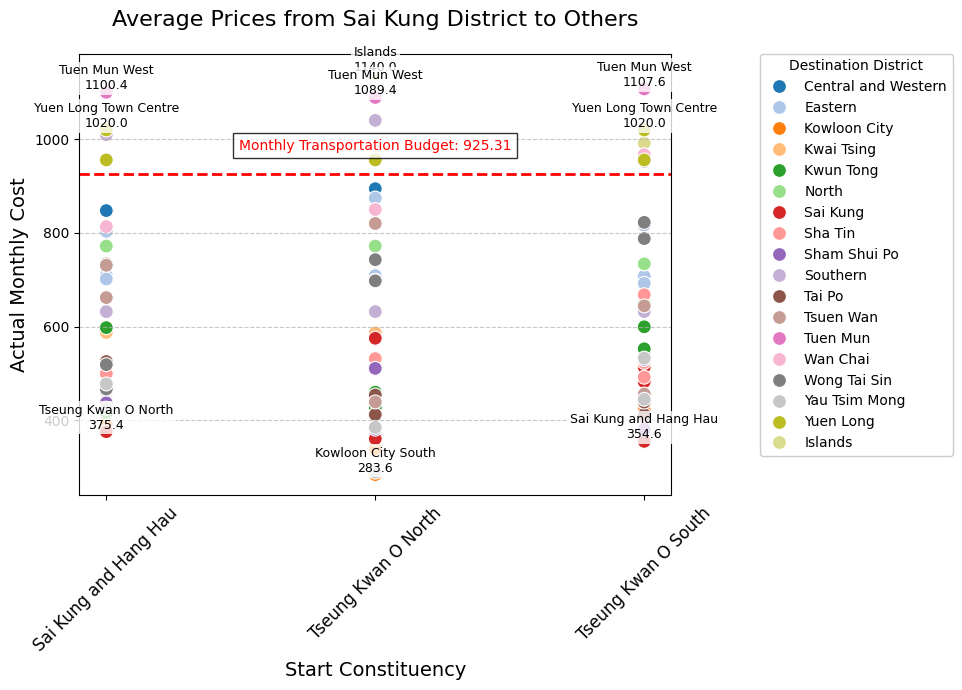

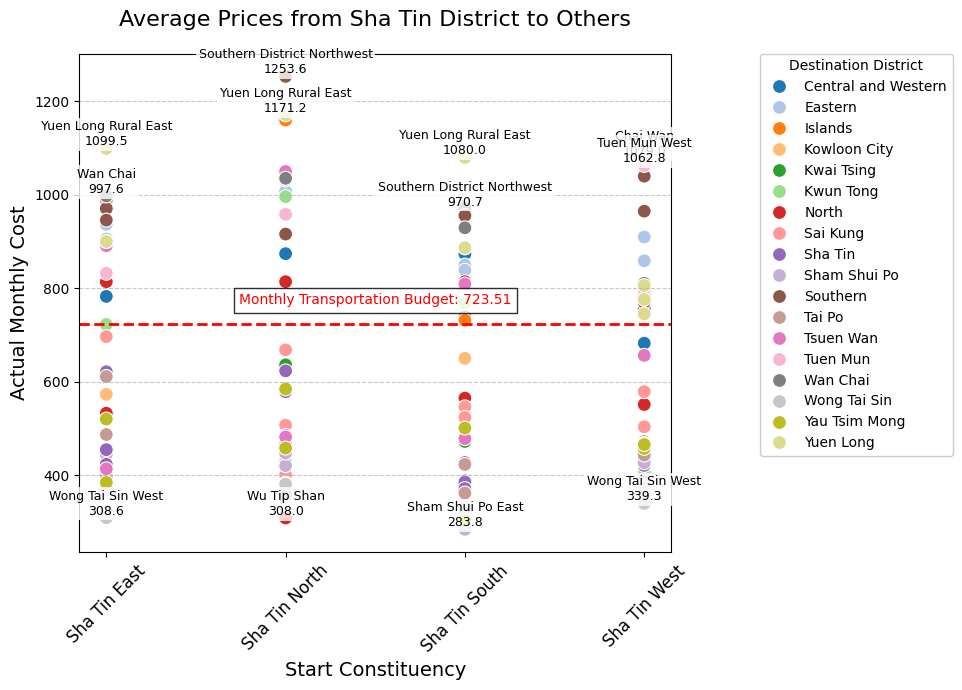

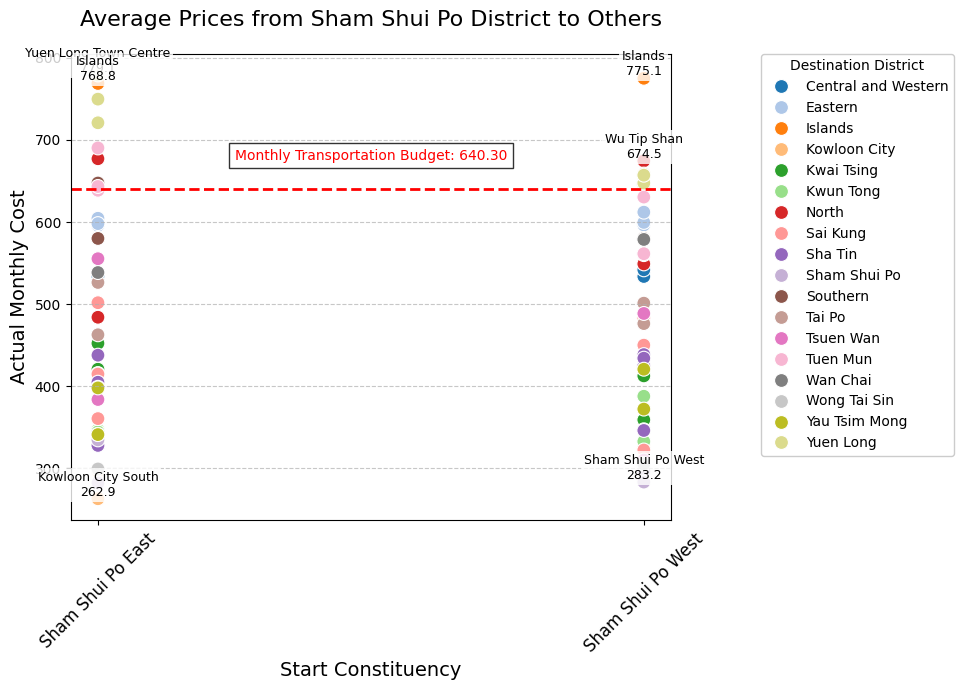

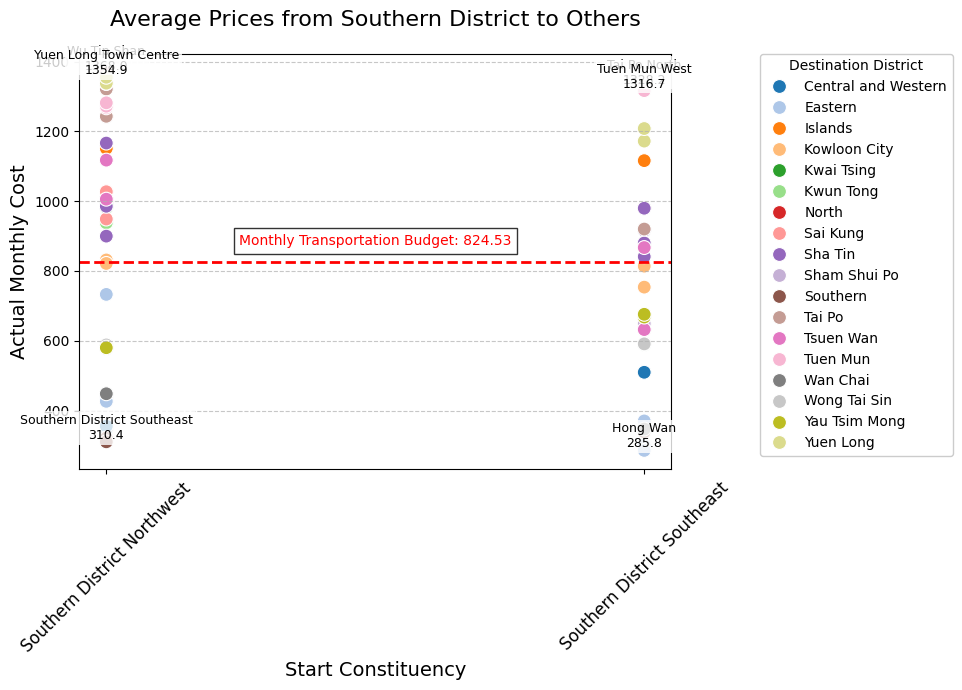

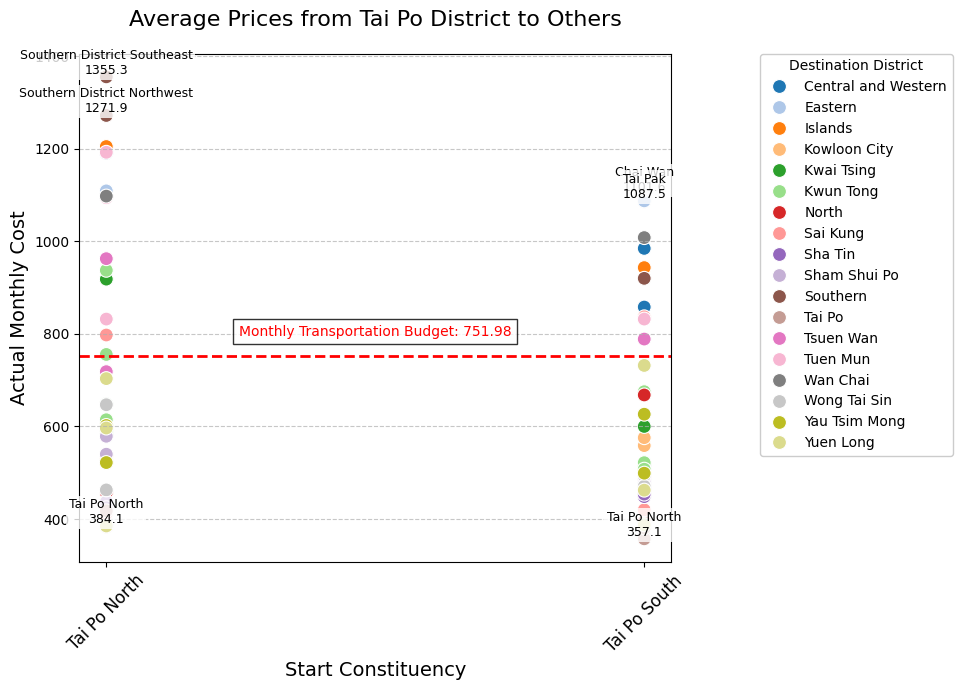

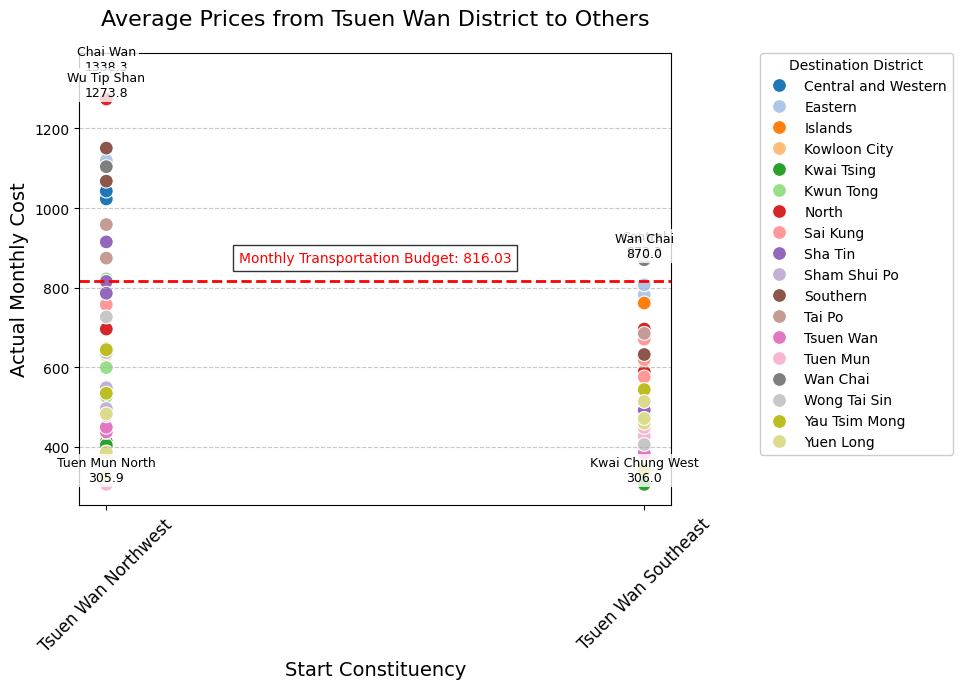

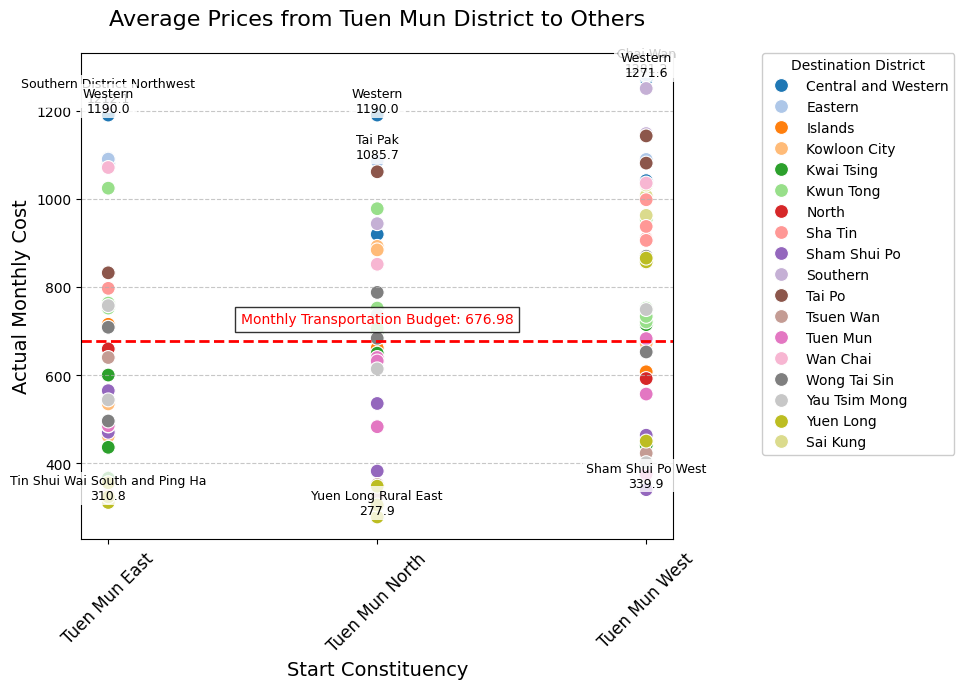

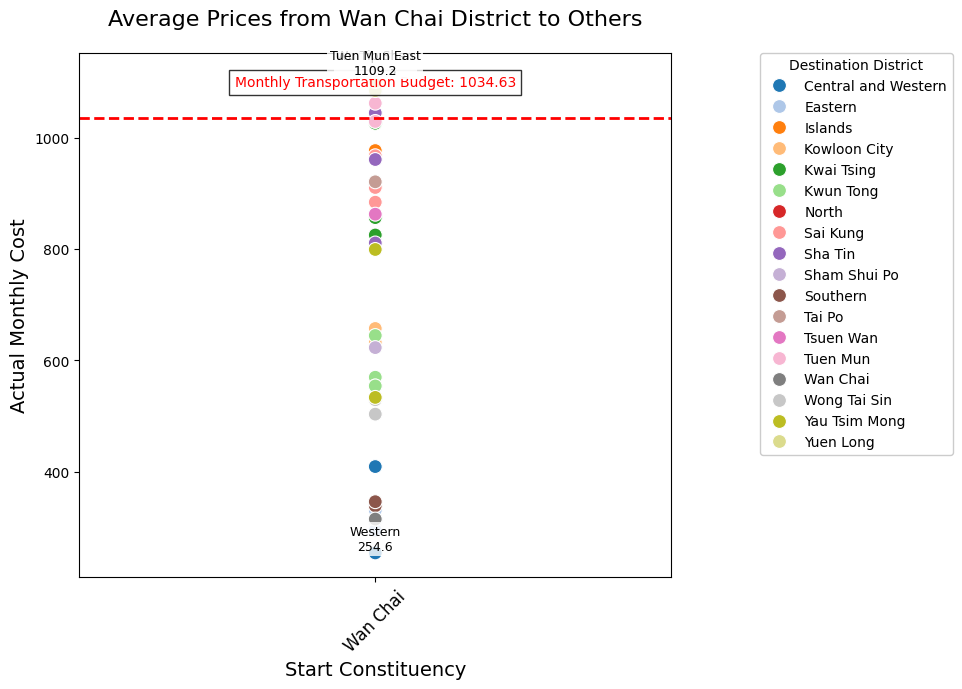

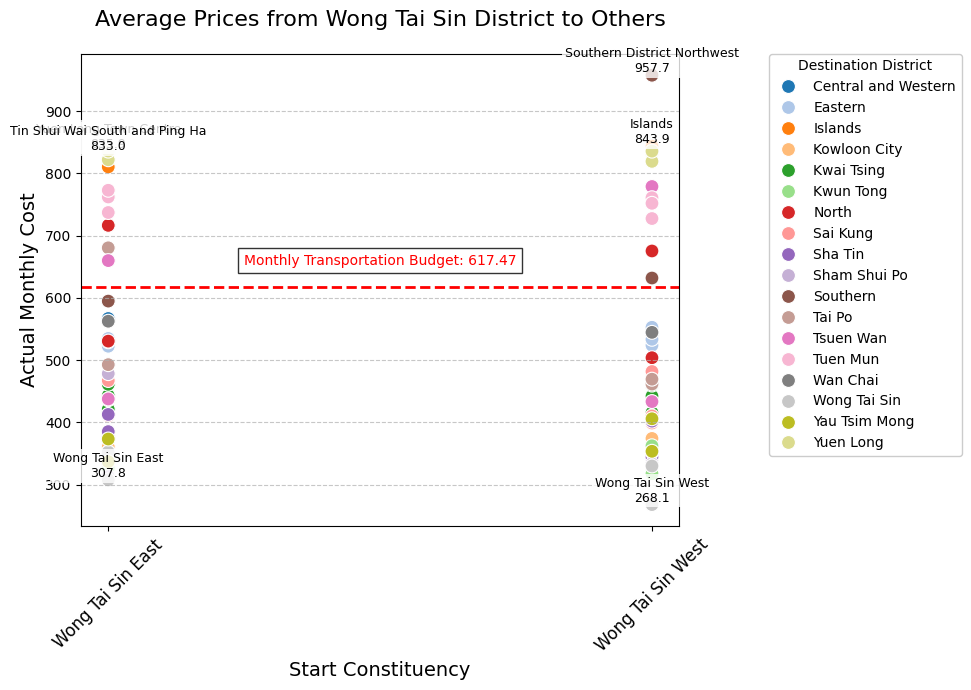

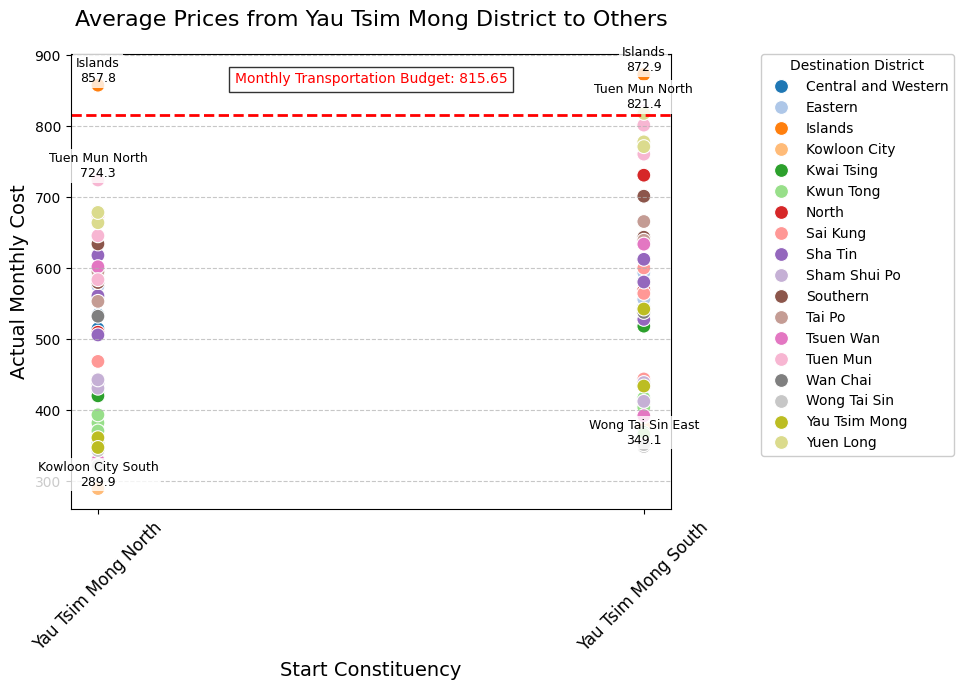

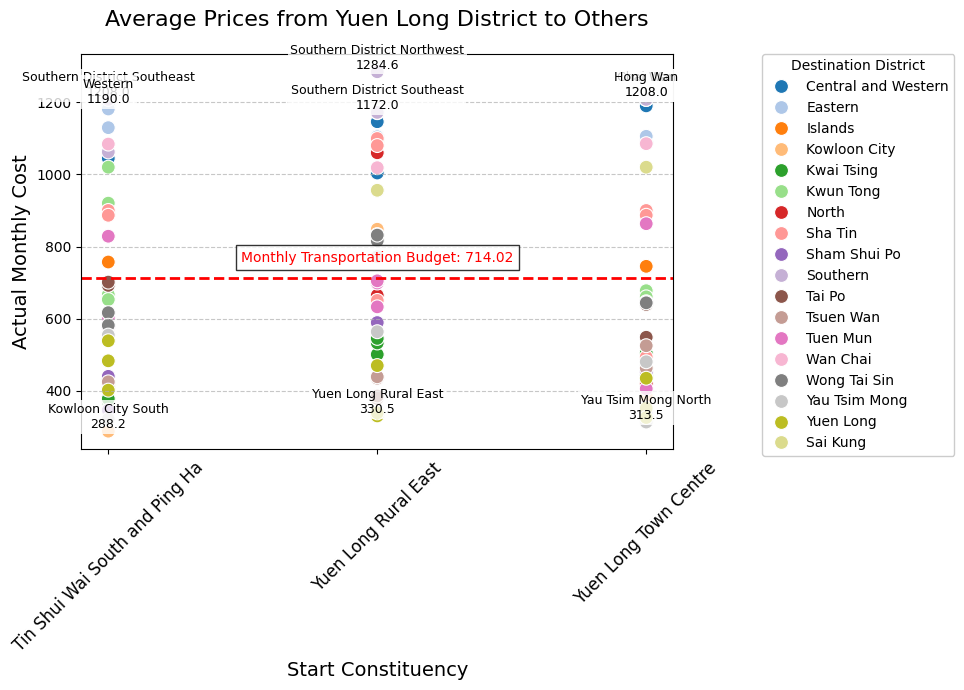

In [30]:
# Create a separate plot for each area
for area in areas:
    plt.figure(figsize=(10, 7))
    
    # Filter data for current area
    area_data = average_prices[average_prices['AREA'] == area].copy()
    
    # Create scatter plot
    ax = sns.scatterplot(data=area_data, x='DISTRICT', y='PRICE', 
                        hue='NEXT AREA', palette='tab20', s=100)
    
    # Add horizontal line
    transport_cost = area_transportation_cost[area]
    ax.axhline(y=transport_cost, color='red', linestyle='--', linewidth=2)
    ax.text(0.5, transport_cost * 1.05, f'Monthly Transportation Budget: {transport_cost:.2f}',
           color='red', ha='center', va='bottom', transform=ax.get_yaxis_transform(),
           bbox=dict(facecolor='white', alpha=0.8))
    
    # For each constituency (x-value), label top 5 points
    for constituency in area_data['DISTRICT'].unique():
        # Get top 2 points for this constituency
        constituency_data = area_data[area_data['DISTRICT'] == constituency]
        top_2 = constituency_data.nlargest(2, 'PRICE')
        # Get bottom 2 points for this constituency
        bottom_2 = constituency_data.nsmallest(1, 'PRICE')
        # Add labels for these bottom 1 points
        for _, row in bottom_2.iterrows():
            ax.text(row['DISTRICT'], row['PRICE'], 
                   f"{row['NEXT DISTRICT']}\n{row['PRICE']:.1f}",
                   fontsize=9, ha='center', va='bottom',
                   bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', pad=2))
        
        # Add labels for these top 2 points
        for _, row in top_2.iterrows():
            ax.text(row['DISTRICT'], row['PRICE'], 
                   f"{row['NEXT DISTRICT']}\n{row['PRICE']:.1f}",
                   fontsize=9, ha='center', va='bottom',
                   bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', pad=2))
    
    # Customize plot
    plt.title(f'Average Prices from {area} District to Others', fontsize=16, pad=20)
    plt.xlabel('Start Constituency', fontsize=14)
    plt.ylabel('Actual Monthly Cost', fontsize=14)
    
    # X-axis handling
    if len(areas_to_districts[area]) == 1:  # Single district
        constituency_name = areas_to_districts[area][0]
        ax.set_xticks([constituency_name])
        ax.set_xticklabels([constituency_name], rotation=45, fontsize=12)
    else:
        plt.xticks(rotation=45, fontsize=12)
        plt.grid(axis='y', linestyle='--', alpha=0.7)
    
    # Legend handling
    plt.legend(title='Destination District', bbox_to_anchor=(1.15, 1), 
              borderaxespad=0, framealpha=1)
    
    plt.tight_layout()
    plt.show()

C:\Users\kelvin wong\AppData\Local\Temp\ipykernel_6004\116395879.py:65: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, fontsize=8)
C:\Users\kelvin wong\AppData\Local\Temp\ipykernel_6004\116395879.py:65: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, fontsize=8)
C:\Users\kelvin wong\AppData\Local\Temp\ipykernel_6004\116395879.py:65: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, fontsize=8)
C:\Users\kelvin wong\AppData\Local\Temp\ipykernel_6004\116395879.py:65: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocat

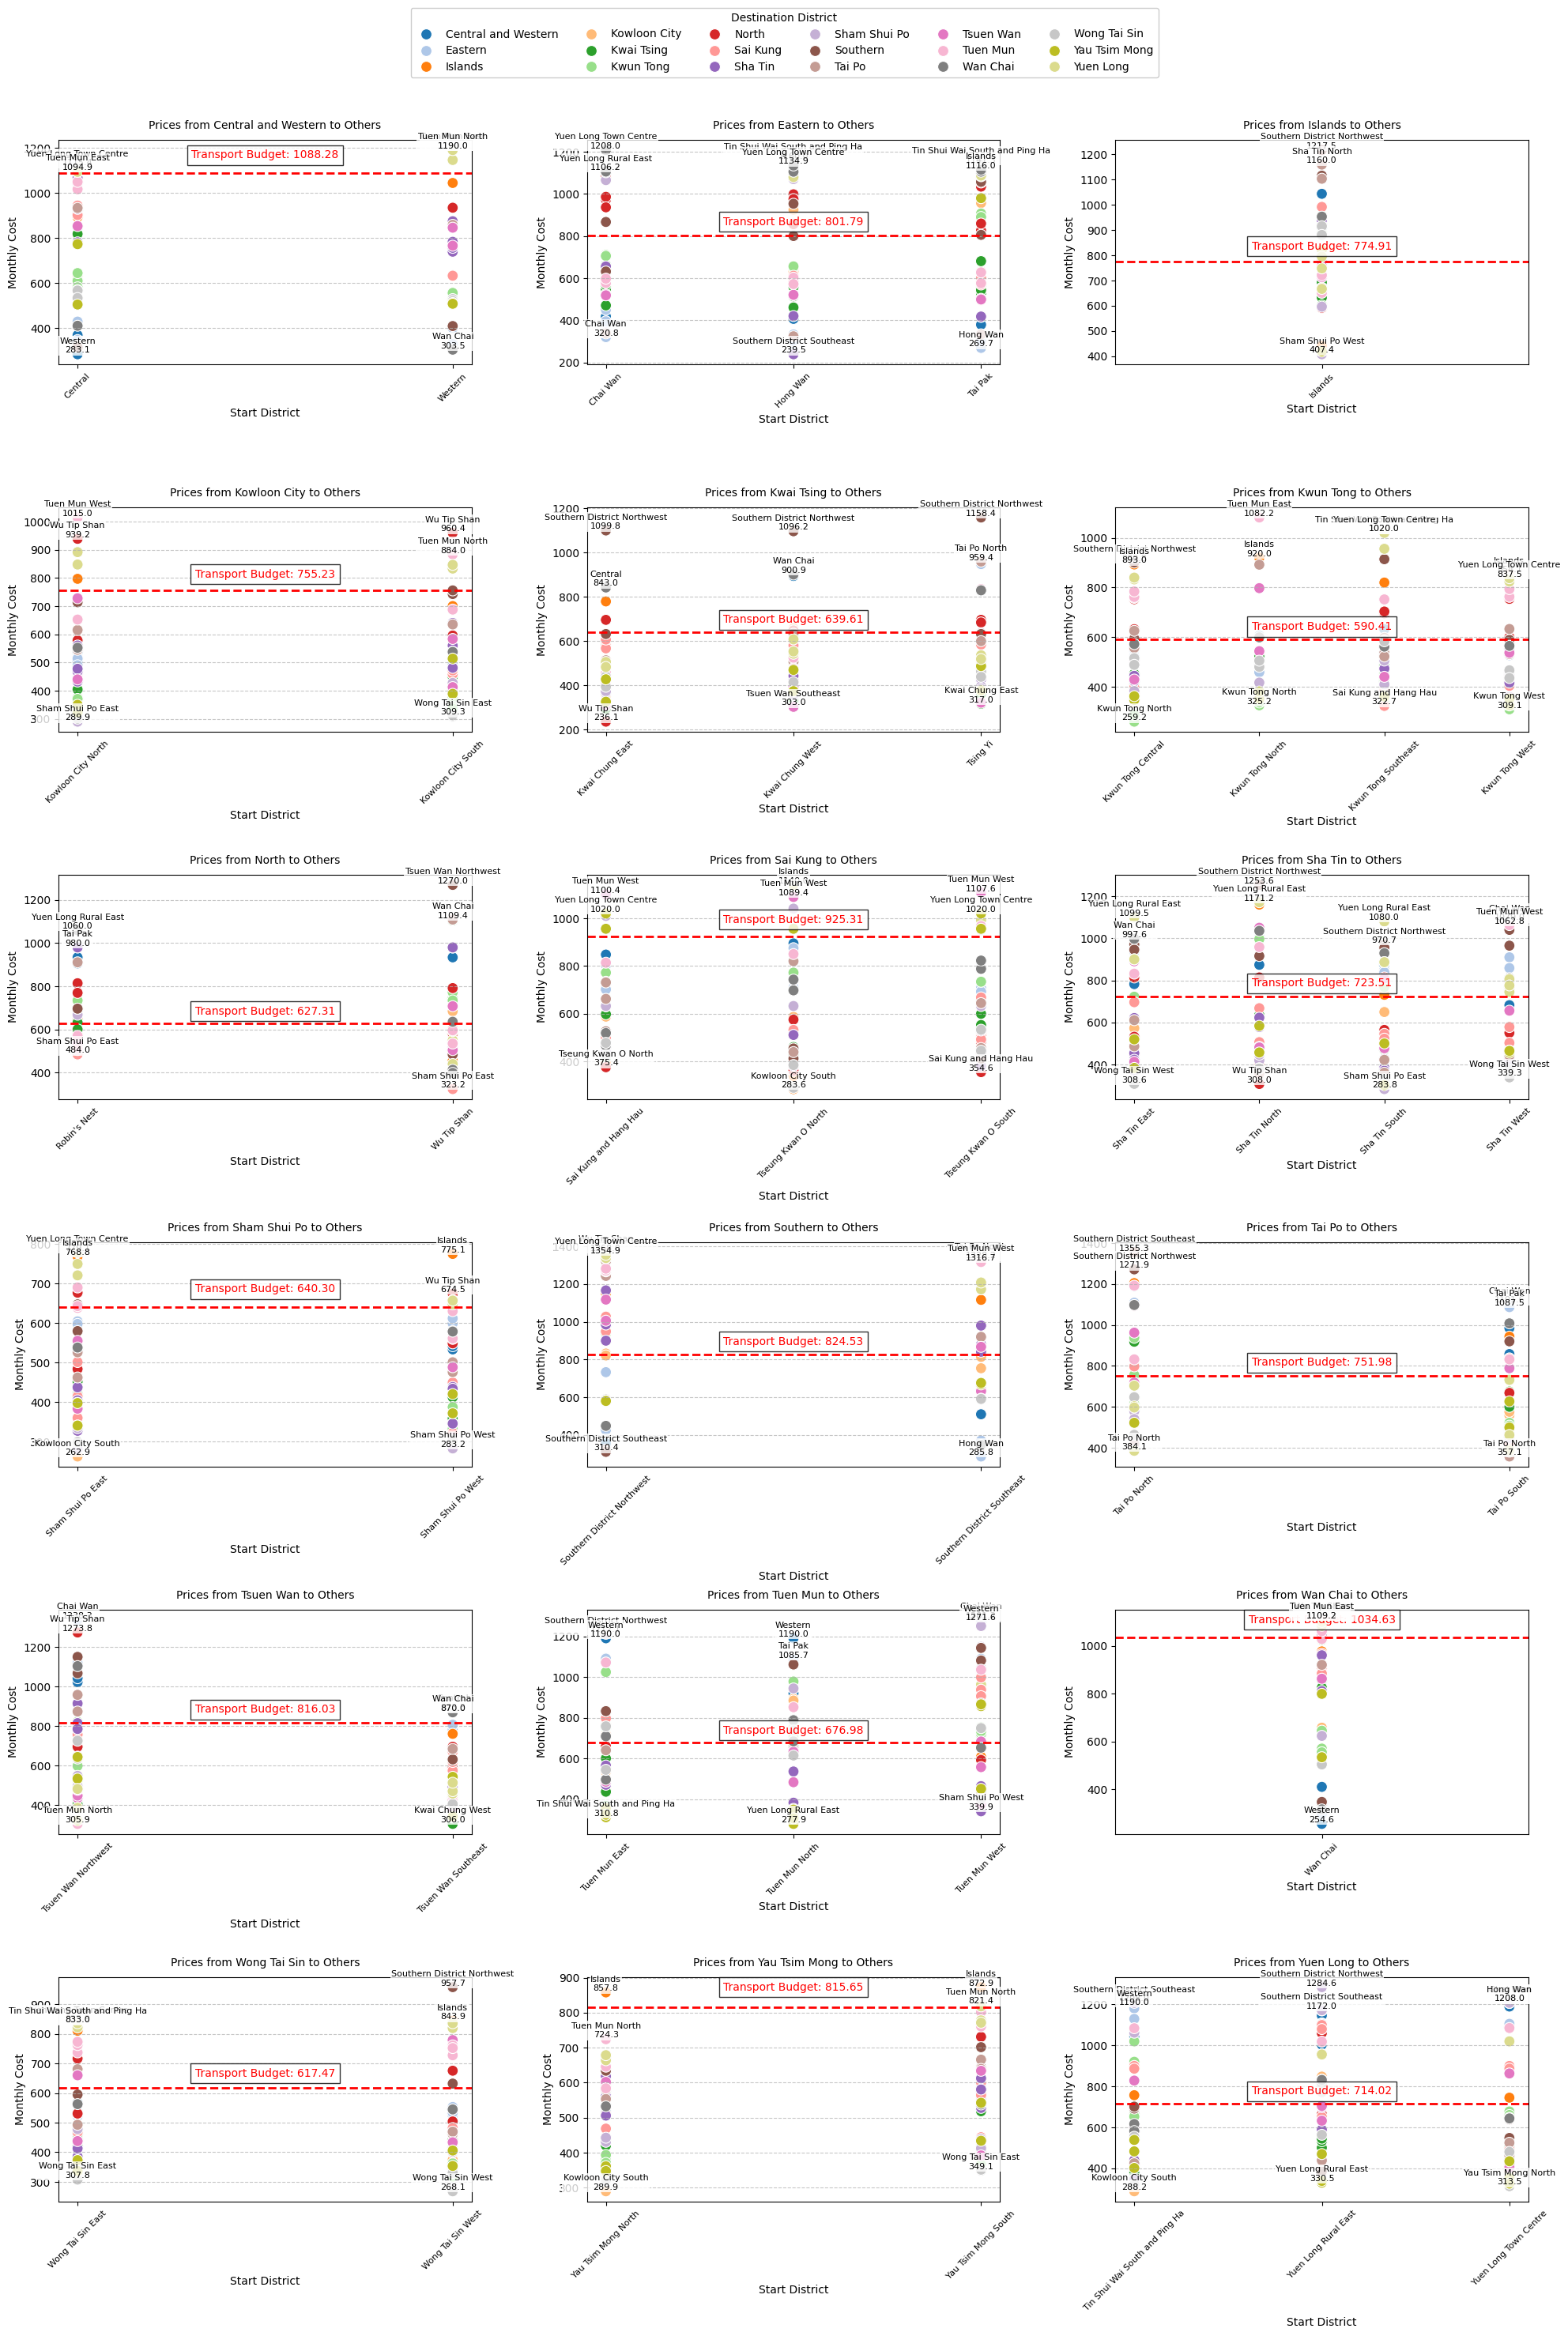

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

areas = ['Central and Western', 'Eastern', 'Islands', 'Kowloon City', 
         'Kwai Tsing', 'Kwun Tong', 'North', 'Sai Kung', 'Sha Tin', 
         'Sham Shui Po', 'Southern', 'Tai Po', 'Tsuen Wan', 'Tuen Mun', 
         'Wan Chai', 'Wong Tai Sin', 'Yau Tsim Mong', 'Yuen Long']

# Create a figure with 9 rows and 2 columns
fig, axes = plt.subplots(6, 3, figsize=(20, 29))  # Adjust size as needed
axes = axes.flatten()  # Flatten the 9x2 array for easier iteration

# Create a list to collect all legend handles and labels
handles, labels = [], []

for i, area in enumerate(areas):
    ax = axes[i]
    
    # Filter data for current area
    area_data = average_prices[average_prices['AREA'] == area].copy()
    
    # Create scatter plot
    scatter = sns.scatterplot(data=area_data, x='DISTRICT', y='PRICE', 
                             hue='NEXT AREA', palette='tab20', s=100, ax=ax)
    
    # Add horizontal line
    transport_cost = area_transportation_cost[area]
    ax.axhline(y=transport_cost, color='red', linestyle='--', linewidth=2)
    ax.text(0.5, transport_cost * 1.05, f'Transport Budget: {transport_cost:.2f}',
           color='red', ha='center', va='bottom', transform=ax.get_yaxis_transform(),
           bbox=dict(facecolor='white', alpha=0.8))
    
    # For each constituency (x-value), label top 5 points
    for constituency in area_data['DISTRICT'].unique():
        # Get top 2 points for this constituency
        constituency_data = area_data[area_data['DISTRICT'] == constituency]
        top_2 = constituency_data.nlargest(2, 'PRICE')
        # Get bottom 2 points for this constituency
        bottom_2 = constituency_data.nsmallest(1, 'PRICE')
        # Add labels for these bottom 1 points
        for _, row in bottom_2.iterrows():
            ax.text(row['DISTRICT'], row['PRICE'], 
                   f"{row['NEXT DISTRICT']}\n{row['PRICE']:.1f}",
                   fontsize=8, ha='center', va='bottom',
                   bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', pad=1))
        
        # Add labels for these top 2 points
        for _, row in top_2.iterrows():
            ax.text(row['DISTRICT'], row['PRICE'], 
                   f"{row['NEXT DISTRICT']}\n{row['PRICE']:.1f}",
                   fontsize=8, ha='center', va='bottom',
                   bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', pad=1))
    
    # Customize plot
    ax.set_title(f'Prices from {area} to Others', fontsize=10, pad=10)
    ax.set_xlabel('Start District', fontsize=10)
    ax.set_ylabel('Monthly Cost', fontsize=10)
    
    # X-axis handling
    if len(areas_to_districts[area]) == 1:  # Single district
        constituency_name = areas_to_districts[area][0]
        ax.set_xticks([constituency_name])
        ax.set_xticklabels([constituency_name], rotation=45, fontsize=8)
    else:
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, fontsize=8)
        ax.grid(axis='y', linestyle='--', alpha=0.7)
    
    # Store the handles and labels for the legend (only once)
    if i == 0:
        handles, labels = ax.get_legend_handles_labels()
    ax.get_legend().remove()  # Remove individual legends

# Adjust layout to prevent overlap
plt.tight_layout()
plt.subplots_adjust(top=0.96)

# Add a single legend ABOVE all subplots
fig.legend(handles, labels, title='Destination District',
           loc='upper center',   # Position at top center
           bbox_to_anchor=(0.5, 1.02),  # Slightly above the subplots
           ncol=6,              # More columns to fit all items
           fontsize=10,
           framealpha=1)

plt.show()